# Spatial Autocorrelation - Retraining Stability Analysis (All Dimensions, 500 Epochs)

This notebook analyzes whether the spatial patterns
of reconstruction error are stable across the 10 retraining runs from notebook 2a.

**Key Questions:**
1. Is the Global Moran's I of reconstruction errors stable across retraining runs?
2. How much variance is there in spatial autocorrelation across runs?
3. Is the spatial structure of errors a reproducible finding?
4. How does spatial autocorrelation compare between AE and PCA across all bottleneck dimensions?

**Approach:**
- Load reconstruction errors from all 10 retraining runs for all dimensions (2D, 4D, 8D, 16D, 32D, 64D, 100D, 128D)
- Compute Global Moran's I for each run and dimension
- Report mean ± std across runs
- Create summary table comparing AE vs PCA across all dimensions

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Spatial statistics
from esda.moran import Moran
from libpysal.weights import Queen



print("Libraries loaded successfully")

Libraries loaded successfully


## Configuration

In [2]:
# Analysis parameters
DIMENSIONS = [2, 4, 8, 16, 32, 64, 100, 128]  # All available dimensions
N_RUNS = 10

# Paths
STABILITY_PATH_TEMPLATE = "../AE_outputs/retraining_stability_500epochs_linscaling/data/stability_checkpoint_{}d.pkl"
CACHE_DIR = "../data/cache/"
DATA_PATH = "../data/census_data/engcensus_cleaned_scaled.parquet"
PCA_PATH_TEMPLATE = "../AE_outputs/engcensus_all/PCA/{}_components.csv"
GEO_PATH = "../data/geofiles/Output_Areas_(December_2021)_Boundaries_EW_BFE_(V9)_and_RUC.geojson"
OUTPUT_DIR = "plots/spatial_autocorr_500ep/"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

print(f"Configuration:")
print(f"  Dimensions: {DIMENSIONS}")
print(f"  Number of runs per dimension: {N_RUNS}")

Configuration:
  Dimensions: [2, 4, 8, 16, 32, 64, 100, 128]
  Number of runs per dimension: 10


## Load Data

In [3]:
# Load spatial weights from cache, or compute from scratch if cache doesn't exist
weights_cache_path = f"{CACHE_DIR}/spatial_weights_queen.pkl"

if os.path.exists(weights_cache_path):
    print("Loading cached spatial weights...")
    with open(weights_cache_path, 'rb') as f:
        w = pickle.load(f)
else:
    print("Cached spatial weights not found. Computing from scratch...")
    print(f"Loading OA geometries from: {GEO_PATH}")
    gdf = gpd.read_file(GEO_PATH)
    gdf = gdf[['OA21CD', 'geometry']].rename(columns={'OA21CD': 'OA'})
    print(f"  Loaded {len(gdf)} OA geometries")

    print("Building Queen contiguity weights matrix (this may take a few minutes)...")
    w = Queen.from_dataframe(gdf)

    # Cache for future use
    with open(weights_cache_path, 'wb') as f:
        pickle.dump(w, f)
    print(f"  Saved spatial weights to {weights_cache_path}")

w.transform = 'R'
print(f"Spatial weights: {w.n} observations, {w.mean_neighbors:.2f} avg neighbors")

Loading cached spatial weights...


Spatial weights: 188880 observations, 5.98 avg neighbors


In [4]:
# Load stability checkpoints for all dimensions
print("Loading stability checkpoints for all dimensions...\n")

stability_data = {}
for dim in DIMENSIONS:
    path = STABILITY_PATH_TEMPLATE.format(dim)
    with open(path, 'rb') as f:
        checkpoint = pickle.load(f)
    stability_data[dim] = checkpoint
    print(f"  {dim}D: {checkpoint['n_runs']} runs loaded")

print(f"\nLoaded checkpoints for {len(stability_data)} dimensions")

Loading stability checkpoints for all dimensions...

  2D: 10 runs loaded
  4D: 10 runs loaded
  8D: 10 runs loaded


  16D: 10 runs loaded


  32D: 10 runs loaded


  64D: 10 runs loaded


  100D: 10 runs loaded


  128D: 10 runs loaded

Loaded checkpoints for 8 dimensions


In [5]:
# Load census data for OA identifiers
print("Loading census data...")

data = pd.read_parquet(DATA_PATH)
data = data.reset_index()
oa_ids = data['OA'].values

print(f"Number of OAs: {len(oa_ids)}")

# Verify OA count matches stability data
first_dim = DIMENSIONS[0]
first_run_errors = stability_data[first_dim]['reco_errors_list'][0]
assert len(oa_ids) == len(first_run_errors), "OA count mismatch!"
print("OA count verified against stability data.")

Loading census data...
Number of OAs: 188880
OA count verified against stability data.


In [6]:
# Load PCA reconstructions for all dimensions
print("Loading PCA reconstructions for all dimensions...\n")

pca_errors = {}
data_indexed = data.set_index("OA")

for dim in DIMENSIONS:
    pca_path = PCA_PATH_TEMPLATE.format(dim)
    pca_reco = pd.read_csv(pca_path, index_col=0)
    
    # Compute PCA reconstruction error (RMSE per OA)
    pca_err = np.sqrt(np.mean((data_indexed - pca_reco) ** 2, axis=1)) * 100
    pca_errors[dim] = pca_err.values
    print(f"  {dim}D: PCA RMSE mean = {pca_err.mean():.4f}%")

print(f"\nLoaded PCA errors for {len(pca_errors)} dimensions")

Loading PCA reconstructions for all dimensions...



  2D: PCA RMSE mean = 5.1771%


  4D: PCA RMSE mean = 4.3460%


  8D: PCA RMSE mean = 3.5391%


  16D: PCA RMSE mean = 2.6862%


  32D: PCA RMSE mean = 1.9414%


  64D: PCA RMSE mean = 1.2965%


  100D: PCA RMSE mean = 0.8940%


  128D: PCA RMSE mean = 0.6835%

Loaded PCA errors for 8 dimensions


In [7]:
# Prepare AE reconstruction errors for all dimensions
print("Preparing AE reconstruction errors for all dimensions...\n")

ae_errors_by_dim = {}

for dim in DIMENSIONS:
    reco_errors_list = stability_data[dim]['reco_errors_list']
    
    # Convert MSE to RMSE for each run
    ae_errors_by_run = []
    for run_idx, reco_err in enumerate(reco_errors_list):
        rmse = np.sqrt(reco_err) * 100
        ae_errors_by_run.append(rmse)
    
    ae_errors_by_dim[dim] = ae_errors_by_run
    
    # Summary stats
    ae_array = np.array(ae_errors_by_run)
    print(f"  {dim}D: AE RMSE mean = {ae_array.mean():.4f}% ± {ae_array.std(axis=0).mean():.4f}%")

print(f"\nPrepared AE errors for {len(ae_errors_by_dim)} dimensions")

Preparing AE reconstruction errors for all dimensions...

  2D: AE RMSE mean = 3.7241% ± 0.2353%
  4D: AE RMSE mean = 3.0429% ± 0.1670%
  8D: AE RMSE mean = 2.4537% ± 0.1128%
  16D: AE RMSE mean = 1.9604% ± 0.0721%
  32D: AE RMSE mean = 1.5277% ± 0.0524%
  64D: AE RMSE mean = 1.0690% ± 0.0341%
  100D: AE RMSE mean = 0.7615% ± 0.0279%
  128D: AE RMSE mean = 0.6410% ± 0.0249%

Prepared AE errors for 8 dimensions


## Global Moran's I: Stability Analysis (All Dimensions)

Compute Global Moran's I for each of the 10 retraining runs across all bottleneck dimensions.

In [8]:
# Compute Global Moran's I for all dimensions and all runs
print(f"Computing Global Moran's I for all dimensions...\n")

all_morans_results = []

for dim in tqdm(DIMENSIONS, desc="Processing dimensions"):
    # AE: Compute for each run
    for run_idx in range(N_RUNS):
        moran = Moran(ae_errors_by_dim[dim][run_idx], w)
        all_morans_results.append({
            'dimension': dim,
            'run': run_idx,
            'method': 'Autoencoder',
            'morans_i': moran.I,
            'p_value': moran.p_sim
        })
    
    # PCA: Single value per dimension
    moran_pca = Moran(pca_errors[dim], w)
    all_morans_results.append({
        'dimension': dim,
        'run': 0,
        'method': 'PCA',
        'morans_i': moran_pca.I,
        'p_value': moran_pca.p_sim
    })

all_morans_df = pd.DataFrame(all_morans_results)
print(f"\nComputed Moran's I for {len(all_morans_df)} cases")

Computing Global Moran's I for all dimensions...



Processing dimensions:   0%|          | 0/8 [00:00<?, ?it/s]

Processing dimensions:  12%|█▎        | 1/8 [00:49<05:43, 49.03s/it]

Processing dimensions:  25%|██▌       | 2/8 [01:35<04:46, 47.79s/it]

Processing dimensions:  38%|███▊      | 3/8 [02:24<04:00, 48.07s/it]

...

Processing dimensions:  75%|███████▌  | 6/8 [04:46<01:35, 47.64s/it]

Processing dimensions:  88%|████████▊ | 7/8 [05:33<00:47, 47.45s/it]

Processing dimensions: 100%|██████████| 8/8 [06:21<00:00, 47.45s/it]

Processing dimensions: 100%|██████████| 8/8 [06:21<00:00, 47.65s/it]


Computed Moran's I for 88 cases


In [9]:
# Create summary table for all dimensions
print("=" * 100)
print("GLOBAL MORAN'S I SUMMARY TABLE (All Dimensions)")
print("=" * 100)

# Compute summary statistics
summary_rows = []

for dim in DIMENSIONS:
    # AE stats
    ae_data = all_morans_df[(all_morans_df['dimension'] == dim) & (all_morans_df['method'] == 'Autoencoder')]
    ae_mean = ae_data['morans_i'].mean()
    ae_std = ae_data['morans_i'].std()
    ae_cv = ae_std / ae_mean * 100
    ae_min = ae_data['morans_i'].min()
    ae_max = ae_data['morans_i'].max()
    
    # PCA stats
    pca_data = all_morans_df[(all_morans_df['dimension'] == dim) & (all_morans_df['method'] == 'PCA')]
    pca_morans = pca_data['morans_i'].values[0]
    
    # Difference
    diff = ae_mean - pca_morans
    
    summary_rows.append({
        'Dimension': f"{dim}D",
        'AE Mean': ae_mean,
        'AE Std': ae_std,
        'AE CV (%)': ae_cv,
        'AE Min': ae_min,
        'AE Max': ae_max,
        'PCA': pca_morans,
        'AE - PCA': diff
    })

summary_df = pd.DataFrame(summary_rows)

# Display formatted table
print("\n")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n" + "=" * 100)

GLOBAL MORAN'S I SUMMARY TABLE (All Dimensions)


Dimension  AE Mean  AE Std  AE CV (%)  AE Min  AE Max    PCA  AE - PCA
       2D   0.4074  0.0085     2.0781  0.3961  0.4218 0.5362   -0.1288
       4D   0.3616  0.0080     2.2105  0.3508  0.3727 0.5152   -0.1537
       8D   0.3162  0.0056     1.7708  0.3099  0.3268 0.5276   -0.2114
      16D   0.3098  0.0033     1.0686  0.3050  0.3141 0.4671   -0.1573
      32D   0.3551  0.0035     0.9792  0.3491  0.3596 0.4437   -0.0885
      64D   0.4195  0.0025     0.5915  0.4134  0.4223 0.4578   -0.0383
     100D   0.4744  0.0027     0.5691  0.4702  0.4806 0.4944   -0.0201
     128D   0.4727  0.0076     1.6038  0.4666  0.4925 0.4947   -0.0220



In [10]:
# Print p-values for all Moran's I tests
print("P-VALUES FOR ALL MORAN'S I TESTS")
print("=" * 80)
print(f"(Permutation-based pseudo p-values from {999} random permutations)")
print(f"Minimum possible p-value = 1/999 = {1/999:.6f}, reported as 0.001\n")

for dim in DIMENSIONS:
    ae_data = all_morans_df[(all_morans_df['dimension'] == dim) & (all_morans_df['method'] == 'Autoencoder')]
    pca_data = all_morans_df[(all_morans_df['dimension'] == dim) & (all_morans_df['method'] == 'PCA')]
    
    ae_pvals = ae_data['p_value'].values
    pca_pval = pca_data['p_value'].values[0]
    
    unique_ae = np.unique(ae_pvals)
    print(f"  {dim:>3}D  AE  (10 runs): {ae_pvals}  | unique: {unique_ae}")
    print(f"  {dim:>3}D  PCA         : {pca_pval}")
    print()

n_significant = (all_morans_df['p_value'] <= 0.05).sum()
print(f"Total tests: {len(all_morans_df)}")
print(f"Significant at p < 0.05: {n_significant}/{len(all_morans_df)}")
print(f"All p-values: {sorted(all_morans_df['p_value'].unique())}")

P-VALUES FOR ALL MORAN'S I TESTS
(Permutation-based pseudo p-values from 999 random permutations)
Minimum possible p-value = 1/999 = 0.001001, reported as 0.001

    2D  AE  (10 runs): [0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001]  | unique: [0.001]
    2D  PCA         : 0.001

    4D  AE  (10 runs): [0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001]  | unique: [0.001]
    4D  PCA         : 0.001

    8D  AE  (10 runs): [0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001]  | unique: [0.001]
    8D  PCA         : 0.001

   16D  AE  (10 runs): [0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001]  | unique: [0.001]
   16D  PCA         : 0.001

   32D  AE  (10 runs): [0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001]  | unique: [0.001]
   32D  PCA         : 0.001

   64D  AE  (10 runs): [0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001]  | unique: [0.001]
   64D  PCA         : 0.001

  100D  AE  (10 runs): [0.001 0.001 0.00

In [11]:
# Publication-ready table
print("\n📊 Publication Table: Global Moran's I Across Dimensions\n")

pub_table = summary_df[['Dimension', 'AE Mean', 'AE Std', 'PCA', 'AE - PCA']].copy()
pub_table.columns = ['Dimension', 'AE (Mean)', 'AE (Std)', 'PCA', 'Δ (AE-PCA)']

print(pub_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Also show which method has lower spatial autocorrelation
print("\n")
for idx, row in summary_df.iterrows():
    dim = row['Dimension']
    diff = row['AE - PCA']
    if diff < 0:
        print(f"  {dim}: AE has LOWER spatial autocorrelation (better)")
    else:
        print(f"  {dim}: PCA has LOWER spatial autocorrelation (better)")


📊 Publication Table: Global Moran's I Across Dimensions

Dimension  AE (Mean)  AE (Std)    PCA  Δ (AE-PCA)
       2D     0.4074    0.0085 0.5362     -0.1288
       4D     0.3616    0.0080 0.5152     -0.1537
       8D     0.3162    0.0056 0.5276     -0.2114
      16D     0.3098    0.0033 0.4671     -0.1573
      32D     0.3551    0.0035 0.4437     -0.0885
      64D     0.4195    0.0025 0.4578     -0.0383
     100D     0.4744    0.0027 0.4944     -0.0201
     128D     0.4727    0.0076 0.4947     -0.0220


  2D: AE has LOWER spatial autocorrelation (better)
  4D: AE has LOWER spatial autocorrelation (better)
  8D: AE has LOWER spatial autocorrelation (better)
  16D: AE has LOWER spatial autocorrelation (better)
  32D: AE has LOWER spatial autocorrelation (better)
  64D: AE has LOWER spatial autocorrelation (better)
  100D: AE has LOWER spatial autocorrelation (better)
  128D: AE has LOWER spatial autocorrelation (better)


## Visualization

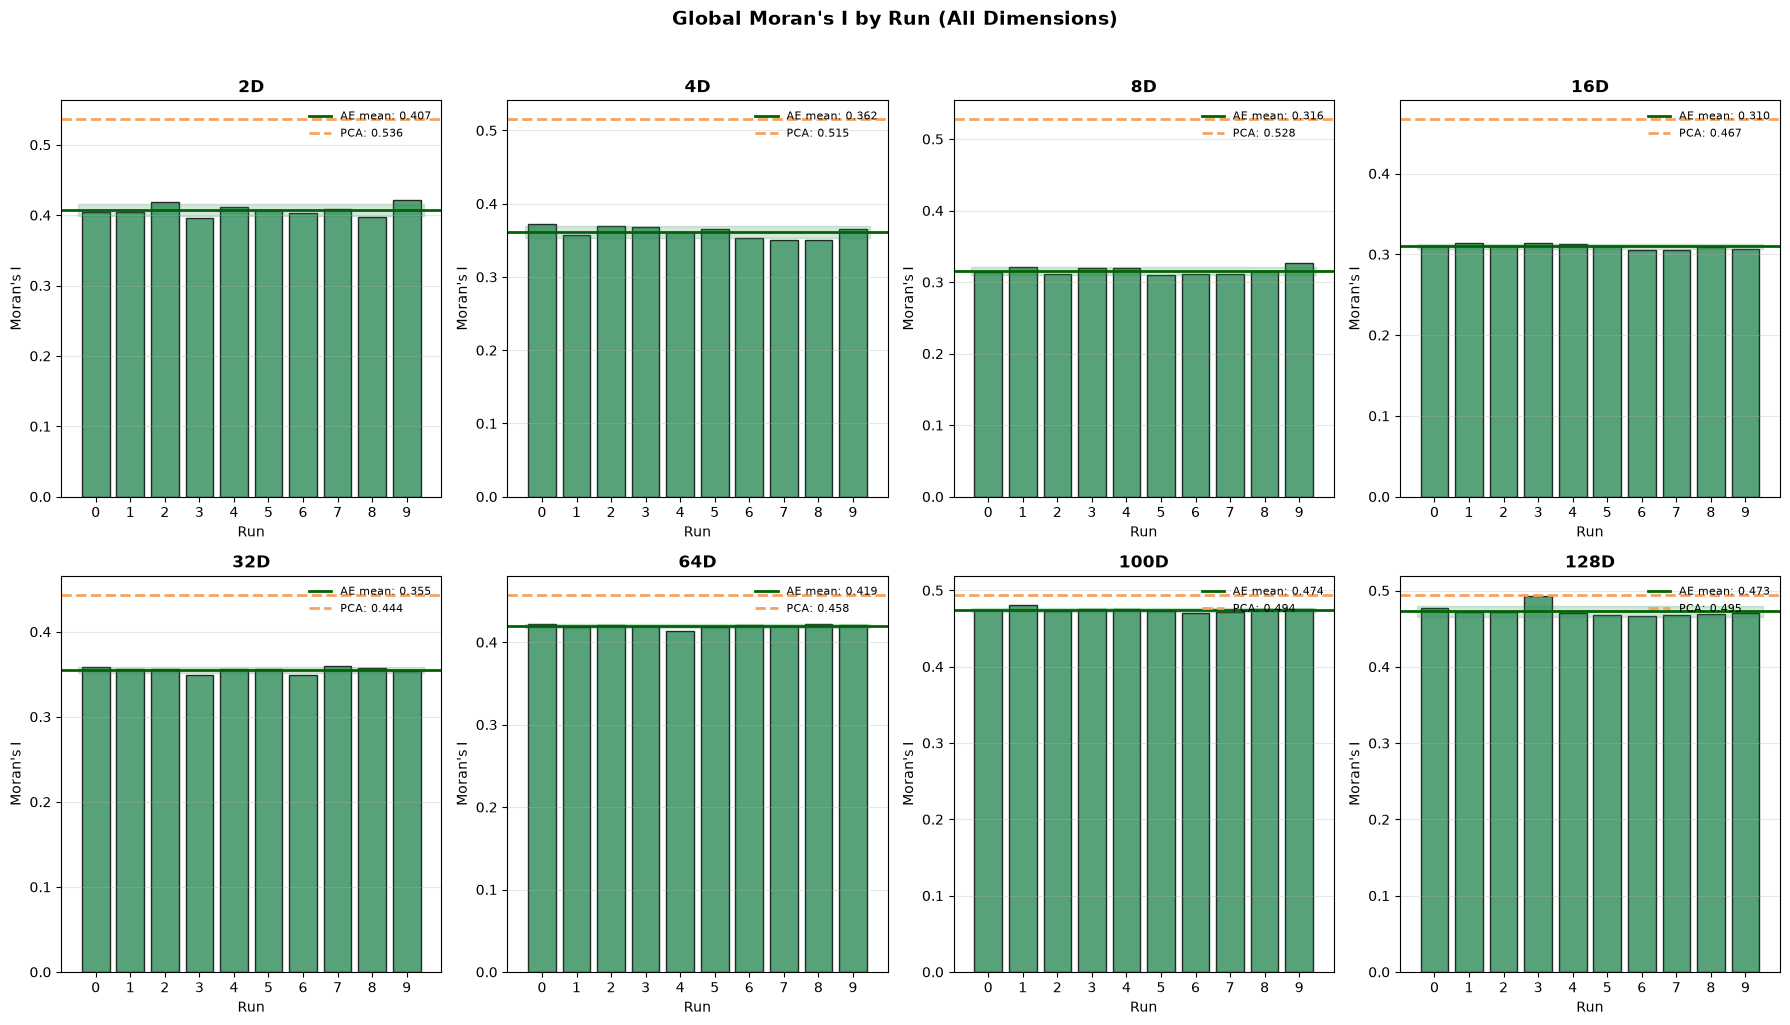

In [12]:
# Plot Moran's I across all dimensions
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, dim in enumerate(DIMENSIONS):
    ax = axes[idx]
    
    # Get data for this dimension
    ae_data = all_morans_df[(all_morans_df['dimension'] == dim) & (all_morans_df['method'] == 'Autoencoder')]
    pca_data = all_morans_df[(all_morans_df['dimension'] == dim) & (all_morans_df['method'] == 'PCA')]
    
    ae_morans_mean = ae_data['morans_i'].mean()
    ae_morans_std = ae_data['morans_i'].std()
    pca_morans_i = pca_data['morans_i'].values[0]
    
    # Plot AE runs
    x = ae_data['run'].values
    ax.bar(x, ae_data['morans_i'].values, color='seagreen', edgecolor='black', alpha=0.8)
    ax.axhline(ae_morans_mean, color='darkgreen', linestyle='-', linewidth=2, label=f'AE mean: {ae_morans_mean:.3f}')
    ax.axhline(pca_morans_i, color='sandybrown', linestyle='--', linewidth=2, label=f'PCA: {pca_morans_i:.3f}')
    ax.fill_between([-0.5, N_RUNS-0.5], ae_morans_mean - ae_morans_std, ae_morans_mean + ae_morans_std, 
                    color='seagreen', alpha=0.2)
    
    ax.set_xlabel('Run', fontsize=10)
    ax.set_ylabel("Moran's I", fontsize=10)
    ax.set_title(f"{dim}D", fontsize=12, fontweight='bold')
    ax.legend(frameon=False, fontsize=8, loc='upper right')
    ax.set_xticks(range(N_RUNS))
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("Global Moran's I by Run (All Dimensions)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/stability_global_morans_all_dims.png", dpi=300, bbox_inches='tight')
plt.show()

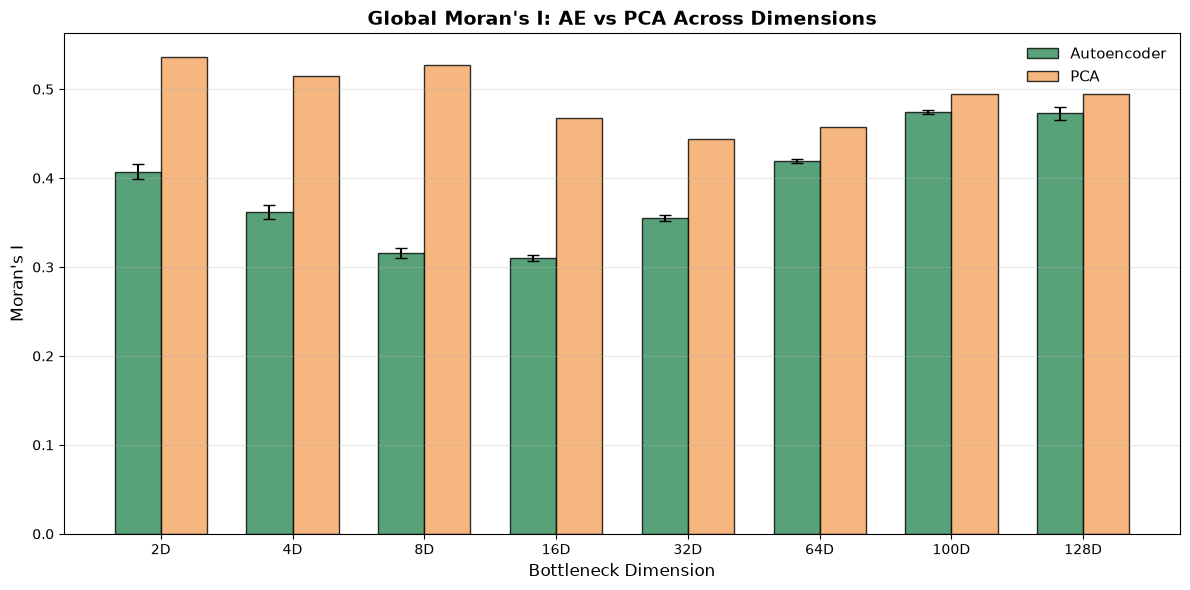

In [13]:
# Summary comparison plot: AE vs PCA across dimensions
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(DIMENSIONS))
width = 0.35

# Extract means and stds
ae_means = [summary_df[summary_df['Dimension'] == f'{d}D']['AE Mean'].values[0] for d in DIMENSIONS]
ae_stds = [summary_df[summary_df['Dimension'] == f'{d}D']['AE Std'].values[0] for d in DIMENSIONS]
pca_vals = [summary_df[summary_df['Dimension'] == f'{d}D']['PCA'].values[0] for d in DIMENSIONS]

# Plot bars
bars_ae = ax.bar(x - width/2, ae_means, width, yerr=ae_stds, capsize=4, 
                  color='seagreen', edgecolor='black', label='Autoencoder', alpha=0.8)
bars_pca = ax.bar(x + width/2, pca_vals, width, 
                   color='sandybrown', edgecolor='black', label='PCA', alpha=0.8)

ax.set_xlabel('Bottleneck Dimension', fontsize=12)
ax.set_ylabel("Moran's I", fontsize=12)
ax.set_title("Global Moran's I: AE vs PCA Across Dimensions", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{d}D' for d in DIMENSIONS])
ax.legend(frameon=False, fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/stability_morans_comparison_all_dims.png", dpi=300, bbox_inches='tight')
plt.show()

## Final Summary

In [14]:
print("=" * 100)
print("SPATIAL AUTOCORRELATION STABILITY SUMMARY (ALL DIMENSIONS)")
print("=" * 100)

print(f"\nConfiguration:")
print(f"  Dimensions analyzed: {DIMENSIONS}")
print(f"  Number of retraining runs: {N_RUNS}")
print(f"  Number of OAs analyzed: {len(oa_ids)}")

print(f"\nKey Findings:")

# Count how many dimensions favor AE vs PCA
ae_better = sum(1 for d in DIMENSIONS if summary_df[summary_df['Dimension'] == f'{d}D']['AE - PCA'].values[0] < 0)
pca_better = len(DIMENSIONS) - ae_better

print(f"  - AE has lower spatial autocorrelation in {ae_better}/{len(DIMENSIONS)} dimensions")
print(f"  - PCA has lower spatial autocorrelation in {pca_better}/{len(DIMENSIONS)} dimensions")

# Mean CV across all dimensions
mean_cv = summary_df['AE CV (%)'].mean()
print(f"  - Mean CV of AE Moran's I across dimensions: {mean_cv:.2f}%")
print(f"  - The spatial pattern of reconstruction errors is highly stable")

print(f"\nInterpretation:")
print(f"  - Both methods show significant positive spatial autocorrelation (p < 0.05)")
print(f"  - Low CV values indicate reproducible spatial patterns across retraining runs")
print("=" * 100)

SPATIAL AUTOCORRELATION STABILITY SUMMARY (ALL DIMENSIONS)

Configuration:
  Dimensions analyzed: [2, 4, 8, 16, 32, 64, 100, 128]
  Number of retraining runs: 10
  Number of OAs analyzed: 188880

Key Findings:
  - AE has lower spatial autocorrelation in 8/8 dimensions
  - PCA has lower spatial autocorrelation in 0/8 dimensions
  - Mean CV of AE Moran's I across dimensions: 1.36%
  - The spatial pattern of reconstruction errors is highly stable

Interpretation:
  - Both methods show significant positive spatial autocorrelation (p < 0.05)
  - Low CV values indicate reproducible spatial patterns across retraining runs


In [15]:
# Save results
summary_df.to_csv(f"{OUTPUT_DIR}/stability_global_morans_summary_all_dims.csv", index=False)
all_morans_df.to_csv(f"{OUTPUT_DIR}/stability_global_morans_by_run_all_dims.csv", index=False)

print(f"Results saved to {OUTPUT_DIR}")
print(f"  - stability_global_morans_summary_all_dims.csv")
print(f"  - stability_global_morans_by_run_all_dims.csv")

# Display final table again for convenience
print("\n" + "=" * 100)
print("FINAL TABLE FOR PAPER")
print("=" * 100)
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Results saved to plots/spatial_autocorr_500ep/
  - stability_global_morans_summary_all_dims.csv
  - stability_global_morans_by_run_all_dims.csv

FINAL TABLE FOR PAPER
Dimension  AE Mean  AE Std  AE CV (%)  AE Min  AE Max    PCA  AE - PCA
       2D   0.4074  0.0085     2.0781  0.3961  0.4218 0.5362   -0.1288
       4D   0.3616  0.0080     2.2105  0.3508  0.3727 0.5152   -0.1537
       8D   0.3162  0.0056     1.7708  0.3099  0.3268 0.5276   -0.2114
      16D   0.3098  0.0033     1.0686  0.3050  0.3141 0.4671   -0.1573
      32D   0.3551  0.0035     0.9792  0.3491  0.3596 0.4437   -0.0885
      64D   0.4195  0.0025     0.5915  0.4134  0.4223 0.4578   -0.0383
     100D   0.4744  0.0027     0.5691  0.4702  0.4806 0.4944   -0.0201
     128D   0.4727  0.0076     1.6038  0.4666  0.4925 0.4947   -0.0220
